# Concentric Reactor 2D Diffusion Model from OpenMC MGXS

This notebook mirrors the 2D finite-difference diffusion workflow used in `reactorModel.ipynb`, but it replaces hand-entered constants with homogenized multigroup constants exported from the OpenMC concentric reactor model.

## Workflow
- Load the built concentric `model.xml` from `openmc/build/concentric/`
- Load the available concentric MGXS export, preferring the two-group file when it exists
- Extract the concentric reactor radii and heights directly from `model.xml`
- Map the exported core, moderator, and reflector constants into a reusable multigroup 2D diffusion solver
- Solve the fixed concentric geometry with the same axial-plus-radial material layering used by the OpenMC model
- Scan an equivalent control-rod insertion model in the same style as `reactorModel.ipynb`

## Scope
This notebook supports either one-group or two-group MGXS exports. The two-group path is the preferred reference for preserving the OpenMC `k_eff` trend.

## 0. Assumptions and Geometry Reduction

This notebook now targets a specific MGXS export directory produced by `openmc/exportMGXS.ipynb`, including resolved-core exports from `group_sweep/group_*`.

When the export contains resolved core domains, the diffusion model maps them into ordered cylindrical zones:
- `core_central_moderator_channel` becomes the inner moderator channel
- `core_fuel_ring_*` become the thin fissile annuli
- `core_heavy_water_coolant_and_moderator` fills the annular gaps and axial end regions inside the fuel element envelope
- `moderator` and `reflector` remain the outer D2O and light-water regions

The equivalent rod model remains an approximation layered on top of the clean export: absorber is inserted down the central channel across the active fuel height. If the selected MGXS export contains higher-order scattering moments, this notebook uses the zeroth moment of the exported scatter matrix because the diffusion solve itself is based on scalar flux and isotropic group-to-group scattering.

In [10]:
import importlib
import json
import re
import sys
import xml.etree.ElementTree as ET
from pathlib import Path
from pprint import pprint

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import backend.reactor_backend.multigroup_diffusion as multigroup_diffusion
from backend.reactor_backend.diffusion import rho_pcm

importlib.reload(multigroup_diffusion)

from backend.reactor_backend.multigroup_diffusion import (
    CylindricalLayeredModel2D,
    CylindricalRegionZone2D,
    MultiGroupRegion,
    build_multigroup_2d_matrices,
    scan_multigroup_rod_worth_2d,
    solve_multigroup_2d,
)

matplotlib.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.35})

print("Imports OK — numpy", np.__version__, "matplotlib", matplotlib.__version__)

Imports OK — numpy 2.4.6 matplotlib 3.10.9


In [11]:
DEFAULT_MGXS_EXPORT_DIR = (
    project_root
    / "openmc"
    / "build"
    / "concentric"
    / "mgxs_export"
    / "group_sweep"
    / "group_2"
)
_FUEL_RING_LABEL_PATTERN = re.compile(r"^core_fuel_ring_(\d+)$")


def require_dir(path: Path) -> Path:
    if not path.exists() or not path.is_dir():
        raise FileNotFoundError(f"Could not find required directory: {path}")
    return path


def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Could not find required file: {path}")
    return path



def load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)



def parse_surface_value(surface: ET.Element) -> float:
    coeffs = [float(token) for token in surface.attrib["coeffs"].split()]
    if surface.attrib["type"] == "z-cylinder":
        return coeffs[-1]
    if surface.attrib["type"] == "z-plane":
        return coeffs[0]
    raise ValueError(f"Unsupported surface type: {surface.attrib['type']}")



def extract_cell_bounds(root: ET.Element, cell_name: str) -> dict[str, float | list[float]]:
    cell = root.find(f".//cell[@name='{cell_name}']")
    if cell is None:
        raise ValueError(f"Could not find cell named {cell_name!r} in model.xml")

    surface_map = {surface.attrib["id"]: surface for surface in root.findall(".//surface")}
    surface_ids = {token.lstrip("-") for token in re.findall(r"-?\d+", cell.attrib["region"])}
    surfaces = [surface_map[surface_id] for surface_id in surface_ids]

    cylinder_radii = sorted(
        parse_surface_value(surface)
        for surface in surfaces
        if surface.attrib["type"] == "z-cylinder"
    )
    z_planes = sorted(
        parse_surface_value(surface)
        for surface in surfaces
        if surface.attrib["type"] == "z-plane"
    )

    if not z_planes:
        raise ValueError(f"Cell {cell_name!r} is missing axial surfaces")

    return {
        "radii_cm": cylinder_radii,
        "r_min_cm": cylinder_radii[0] if len(cylinder_radii) > 1 else 0.0,
        "r_max_cm": cylinder_radii[-1] if cylinder_radii else 0.0,
        "z_min_cm": z_planes[0],
        "z_max_cm": z_planes[-1],
        "height_cm": z_planes[-1] - z_planes[0],
    }



def scatter_matrix_from_group_constants(group_constants: dict) -> np.ndarray:
    scatter = np.asarray(group_constants["scatter matrix"]["mean"], dtype=float)
    if scatter.ndim == 2:
        return scatter
    if scatter.ndim == 3:
        return scatter[0]
    raise ValueError(f"Unsupported scatter matrix shape {scatter.shape}")



def region_from_mgxs(export: dict, domain_label: str) -> MultiGroupRegion:
    group_constants = export["domains"][domain_label]["group_constants"]
    return MultiGroupRegion(
        name=domain_label,
        diffusion=group_constants["diffusion-coefficient"]["mean"],
        absorption=group_constants["absorption"]["mean"],
        nu_fission=group_constants["nu-fission"]["mean"],
        chi=group_constants["chi"]["mean"],
        scatter=scatter_matrix_from_group_constants(group_constants),
    ).sanitized()



def region_report(region: MultiGroupRegion) -> dict:
    return {
        "diffusion": region.diffusion.tolist(),
        "absorption": region.absorption.tolist(),
        "nu_fission": region.nu_fission.tolist(),
        "chi": region.chi.tolist(),
        "scatter": region.scatter.tolist(),
    }



def format_group_values(values) -> str:
    arr = np.asarray(values, dtype=float).reshape(-1)
    return "[" + ", ".join(f"{value:.6g}" for value in arr) + "]"



def sorted_resolved_fuel_ring_labels(export: dict) -> list[str]:
    labels = []
    for label in export["domains"]:
        match = _FUEL_RING_LABEL_PATTERN.match(label)
        if match is None:
            continue
        labels.append((int(match.group(1)), label))
    return [label for _, label in sorted(labels)]



def extract_concentric_geometry(model_xml_path: Path) -> dict[str, object]:
    root = ET.parse(model_xml_path).getroot()
    fuel_element = extract_cell_bounds(root, "fuel_element")
    moderator = extract_cell_bounds(root, "d2o_tank")
    reflector = extract_cell_bounds(root, "h2o_tank")
    control_rod = extract_cell_bounds(root, "control_rod")

    geometry: dict[str, object] = {
        "fuel_element_radius_cm": float(fuel_element["r_max_cm"]),
        "fuel_element_height_cm": float(fuel_element["height_cm"]),
        "moderator_radius_cm": float(moderator["r_max_cm"]),
        "moderator_height_cm": float(moderator["height_cm"]),
        "reflector_radius_cm": float(reflector["r_max_cm"]),
        "reflector_height_cm": float(reflector["height_cm"]),
        "outer_height_cm": float(max(moderator["height_cm"], reflector["height_cm"])),
        "rod_radius_cm": float(control_rod["r_max_cm"]),
        "parked_rod_z_min_cm": float(control_rod["z_min_cm"]),
        "parked_rod_z_max_cm": float(control_rod["z_max_cm"]),
    }

    fuel_ring_names = sorted(
        name
        for name in {
            cell.attrib["name"]
            for cell in root.findall(".//cell")
            if "name" in cell.attrib
        }
        if re.match(r"^fuel_ring_\d+$", name)
    )
    if fuel_ring_names:
        fuel_rings = [extract_cell_bounds(root, name) for name in fuel_ring_names]
        geometry["core_radius_cm"] = float(fuel_element["r_max_cm"])
        geometry["core_height_cm"] = float(fuel_rings[0]["height_cm"])
        geometry["axial_moderator_extension_cm"] = 0.5 * (
            float(fuel_element["height_cm"]) - float(fuel_rings[0]["height_cm"])
        )
        geometry["central_channel_radius_cm"] = float(extract_cell_bounds(root, "central_moderator_channel")["r_max_cm"])
        geometry["fuel_rings"] = [
            {
                "cell_name": name,
                "r_min_cm": float(bounds["r_min_cm"]),
                "r_max_cm": float(bounds["r_max_cm"]),
                "z_min_cm": float(bounds["z_min_cm"]),
                "z_max_cm": float(bounds["z_max_cm"]),
            }
            for name, bounds in zip(fuel_ring_names, fuel_rings, strict=True)
        ]
    else:
        geometry["core_radius_cm"] = float(fuel_element["r_max_cm"])
        geometry["core_height_cm"] = float(fuel_element["height_cm"])
        geometry["axial_moderator_extension_cm"] = 0.5 * (
            float(moderator["height_cm"]) - float(fuel_element["height_cm"])
        )
        geometry["central_channel_radius_cm"] = float(control_rod["r_max_cm"])
        geometry["fuel_rings"] = []

    return geometry



def build_resolved_zones(export: dict, geometry: dict[str, object]) -> tuple[tuple[CylindricalRegionZone2D, ...], dict[str, MultiGroupRegion], list[dict[str, float | str]]]:
    fuel_ring_labels = sorted_resolved_fuel_ring_labels(export)
    if not fuel_ring_labels:
        return (), {}, []

    regions = {label: region_from_mgxs(export, label) for label in fuel_ring_labels}
    regions["core_central_moderator_channel"] = region_from_mgxs(export, "core_central_moderator_channel")
    regions["core_heavy_water_coolant_and_moderator"] = region_from_mgxs(export, "core_heavy_water_coolant_and_moderator")
    if "core_control_rod" in export["domains"]:
        regions["core_control_rod"] = region_from_mgxs(export, "core_control_rod")

    core_height = float(geometry["core_height_cm"])
    fuel_element_height = float(geometry["fuel_element_height_cm"])
    core_radius = float(geometry["core_radius_cm"])
    moderator_height = float(geometry["moderator_height_cm"])
    moderator_radius = float(geometry["moderator_radius_cm"])
    parked_rod_z_min = float(geometry["parked_rod_z_min_cm"])
    parked_rod_z_max = float(geometry["parked_rod_z_max_cm"])
    central_radius = float(geometry["central_channel_radius_cm"])

    zones = [
        CylindricalRegionZone2D(
            region=region_from_mgxs(export, "moderator"),
            r_max=moderator_radius,
            z_min=-0.5 * moderator_height,
            z_max=0.5 * moderator_height,
        ),
        CylindricalRegionZone2D(
            region=regions["core_heavy_water_coolant_and_moderator"],
            r_max=core_radius,
            z_min=-0.5 * fuel_element_height,
            z_max=0.5 * fuel_element_height,
        ),
        CylindricalRegionZone2D(
            region=regions["core_central_moderator_channel"],
            r_max=central_radius,
            z_min=-0.5 * fuel_element_height,
            z_max=0.5 * core_height,
        ),
    ]

    zone_report_rows = [
        {
            "label": "moderator",
            "region": "moderator",
            "r_min_cm": 0.0,
            "r_max_cm": moderator_radius,
            "z_min_cm": -0.5 * moderator_height,
            "z_max_cm": 0.5 * moderator_height,
        },
        {
            "label": "core_heavy_water_coolant_and_moderator",
            "region": "core_heavy_water_coolant_and_moderator",
            "r_min_cm": 0.0,
            "r_max_cm": core_radius,
            "z_min_cm": -0.5 * fuel_element_height,
            "z_max_cm": 0.5 * fuel_element_height,
        },
        {
            "label": "core_central_moderator_channel",
            "region": "core_central_moderator_channel",
            "r_min_cm": 0.0,
            "r_max_cm": central_radius,
            "z_min_cm": -0.5 * fuel_element_height,
            "z_max_cm": 0.5 * core_height,
        },
    ]

    ring_geometry_by_label = {
        f"core_{entry['cell_name']}": entry
        for entry in geometry["fuel_rings"]
    }
    for label in fuel_ring_labels:
        bounds = ring_geometry_by_label[label]
        zones.append(
            CylindricalRegionZone2D(
                region=regions[label],
                r_min=float(bounds["r_min_cm"]),
                r_max=float(bounds["r_max_cm"]),
                z_min=float(bounds["z_min_cm"]),
                z_max=float(bounds["z_max_cm"]),
            )
        )
        zone_report_rows.append(
            {
                "label": label,
                "region": label,
                "r_min_cm": float(bounds["r_min_cm"]),
                "r_max_cm": float(bounds["r_max_cm"]),
                "z_min_cm": float(bounds["z_min_cm"]),
                "z_max_cm": float(bounds["z_max_cm"]),
            }
        )

    if "core_control_rod" in regions:
        zones.append(
            CylindricalRegionZone2D(
                region=regions["core_control_rod"],
                r_max=float(geometry["rod_radius_cm"]),
                z_min=parked_rod_z_min,
                z_max=parked_rod_z_max,
            )
        )
        zone_report_rows.append(
            {
                "label": "core_control_rod",
                "region": "core_control_rod",
                "r_min_cm": 0.0,
                "r_max_cm": float(geometry["rod_radius_cm"]),
                "z_min_cm": parked_rod_z_min,
                "z_max_cm": parked_rod_z_max,
            }
        )

    return tuple(zones), regions, zone_report_rows

## 1. Select a Specific OpenMC MGXS Export

Point `MGXS_EXPORT_DIR` at the exact export you want to use from `openmc/exportMGXS.ipynb`. This can be a resolved-core export inside `group_sweep/group_*`.

The notebook derives both paths from that directory:
- `reactor_run/model.xml`
- `outputs/mgxs_constants.json`

This avoids guessing which export is the latest and makes it easy to compare different group counts or scattering-moment runs.

In [12]:
MGXS_EXPORT_DIR = DEFAULT_MGXS_EXPORT_DIR
MODEL_XML_PATH = require_file(MGXS_EXPORT_DIR / "reactor_run" / "model.xml")
MGXS_JSON_PATH = require_file(MGXS_EXPORT_DIR / "outputs" / "mgxs_constants.json")

P_MW = 20.0
P_W = P_MW * 1e6

MGXS_EXPORT_DIR = require_dir(MGXS_EXPORT_DIR)
MGXS_EXPORT = load_json(MGXS_JSON_PATH)
GEOMETRY = extract_concentric_geometry(MODEL_XML_PATH)
DOMAIN_LABELS = list(MGXS_EXPORT["domains"].keys())
IS_RESOLVED_CORE = any(label.startswith("core_fuel_ring_") for label in DOMAIN_LABELS)

MODERATOR_REGION = region_from_mgxs(MGXS_EXPORT, "moderator")
REFLECTOR_REGION = region_from_mgxs(MGXS_EXPORT, "reflector")

if IS_RESOLVED_CORE:
    RESOLVED_ZONES, RESOLVED_REGIONS, RESOLVED_ZONE_REPORT = build_resolved_zones(MGXS_EXPORT, GEOMETRY)
    CORE_REFERENCE_REGION = RESOLVED_REGIONS[sorted_resolved_fuel_ring_labels(MGXS_EXPORT)[0]]
    CORE_REGION = CORE_REFERENCE_REGION
else:
    CORE_REGION = region_from_mgxs(MGXS_EXPORT, "core")
    CORE_REFERENCE_REGION = CORE_REGION
    RESOLVED_ZONES = ()
    RESOLVED_REGIONS = {}
    RESOLVED_ZONE_REPORT = []

GROUP_COUNT = CORE_REFERENCE_REGION.group_count
TRANSPORT_KEFF = float(MGXS_EXPORT["run"]["keff"]["mean"])
TRANSPORT_RHO_PCM = float(MGXS_EXPORT["run"]["reactivity_pcm"])
SCATTER_LEGENDRE_ORDER = int(MGXS_EXPORT["config"].get("legendre_order", 0))

NOTEBOOK_REPORT = {
    "mgxs_export_dir": str(MGXS_EXPORT_DIR),
    "model_xml_path": str(MODEL_XML_PATH),
    "mgxs_json_path": str(MGXS_JSON_PATH),
    "group_count": GROUP_COUNT,
    "resolved_core": IS_RESOLVED_CORE,
    "scatter_legendre_order": SCATTER_LEGENDRE_ORDER,
    "geometry": GEOMETRY,
    "domain_labels": DOMAIN_LABELS,
    "resolved_zone_count": len(RESOLVED_ZONES),
    "resolved_zones": RESOLVED_ZONE_REPORT,
    "regions": {
        "core_reference": region_report(CORE_REFERENCE_REGION),
        "moderator": region_report(MODERATOR_REGION),
        "reflector": region_report(REFLECTOR_REGION),
    },
    "openmc_reference": {
        "keff": TRANSPORT_KEFF,
        "reactivity_pcm": TRANSPORT_RHO_PCM,
    },
}

pprint(NOTEBOOK_REPORT, sort_dicts=False)

{'mgxs_export_dir': '/home/pablo/modelica/ReactorKineticsLab/openmc/build/concentric/mgxs_export/group_sweep/group_2',
 'model_xml_path': '/home/pablo/modelica/ReactorKineticsLab/openmc/build/concentric/mgxs_export/group_sweep/group_2/reactor_run/model.xml',
 'mgxs_json_path': '/home/pablo/modelica/ReactorKineticsLab/openmc/build/concentric/mgxs_export/group_sweep/group_2/outputs/mgxs_constants.json',
 'group_count': 2,
 'resolved_core': True,
 'scatter_legendre_order': 0,
 'geometry': {'fuel_element_radius_cm': 50.0,
              'fuel_element_height_cm': 400.0,
              'moderator_radius_cm': 250.0,
              'moderator_height_cm': 600.0,
              'reflector_radius_cm': 500.0,
              'reflector_height_cm': 1000.0,
              'outer_height_cm': 1000.0,
              'rod_radius_cm': 4.0,
              'parked_rod_z_min_cm': 150.0,
              'parked_rod_z_max_cm': 200.0,
              'core_radius_cm': 50.0,
              'core_height_cm': 300.0,
          

## 2. Build the 2D Diffusion Model

If the selected export is resolved, the solver uses the resolved cylindrical zones directly:
- outer D2O moderator tank
- heavy-water coolant and moderator inside the fuel-element envelope
- central moderator channel
- each `fuel_ring_*` annulus
- parked control-rod segment when present

If the selected export is still a supercell export, the notebook falls back to the older three-region layered map.

The rod scan remains an equivalent perturbation inserted down the central channel across the active fuel height.

In [14]:
DELTA_SIGMA_A_ROD = 0.25  # scalar equivalent absorber increment applied to each group
DR_CM = 2.0
DZ_CM = 2.0

model_2d = CylindricalLayeredModel2D(
    core_radius=GEOMETRY["core_radius_cm"],
    moderator_radius=GEOMETRY["moderator_radius_cm"],
    reflector_radius=GEOMETRY["reflector_radius_cm"],
    core_height=GEOMETRY["core_height_cm"],
    outer_height=GEOMETRY["outer_height_cm"],
    core=CORE_REFERENCE_REGION,
    moderator=MODERATOR_REGION,
    reflector=REFLECTOR_REGION,
    rod_radius=GEOMETRY["rod_radius_cm"],
    delta_absorption_rod=DELTA_SIGMA_A_ROD,
    zones=RESOLVED_ZONES,
)

operator_matrix, _, _, _, nr, nz, group_count = build_multigroup_2d_matrices(
    model_2d,
    DR_CM,
    DZ_CM,
    x_insert=0.0,
)
print("=== CONCENTRIC 2D DIFFUSION MODEL ===")
print(f"Resolved core geometry   = {IS_RESOLVED_CORE}")
print(f"Energy groups           = {group_count}")
print(f"Scatter moment in MGXS  = P{SCATTER_LEGENDRE_ORDER} (diffusion uses P0)")
print(f"Core radius             = {GEOMETRY['core_radius_cm']:.1f} cm")
print(f"Fuel envelope height    = {GEOMETRY['fuel_element_height_cm']:.1f} cm")
print(f"Active fuel height      = {GEOMETRY['core_height_cm']:.1f} cm")
print(f"Moderator outer radius  = {GEOMETRY['moderator_radius_cm']:.1f} cm")
print(f"Reflector outer radius  = {GEOMETRY['reflector_radius_cm']:.1f} cm")
print(f"Outer tank height       = {GEOMETRY['outer_height_cm']:.1f} cm")
print(f"Axial D2O extension     = {GEOMETRY['axial_moderator_extension_cm']:.1f} cm per side")
print(f"Equivalent rod radius   = {GEOMETRY['rod_radius_cm']:.1f} cm")
print(f"Equivalent rod dSigma_a = {DELTA_SIGMA_A_ROD:.3f} cm^-1")
print()
print(f"Mesh size               = dr = {DR_CM:.1f} cm, dz = {DZ_CM:.1f} cm")
print(f"2D matrix size          = {nr} x {nz} = {nr*nz:,} cells")
print(f"Sparse nnz              = {operator_matrix.nnz:,}")
print()

if IS_RESOLVED_CORE:
    print("Resolved zones")
    for zone in RESOLVED_ZONE_REPORT:
        region = RESOLVED_REGIONS.get(zone["region"], MODERATOR_REGION if zone["region"] == "moderator" else REFLECTOR_REGION)
        print(
            f"{zone['label']:>36}: "
            f"r=[{zone['r_min_cm']:.1f}, {zone['r_max_cm']:.1f}) cm, "
            f"z=[{zone['z_min_cm']:.1f}, {zone['z_max_cm']:.1f}) cm, "
            f"Sigma_a={format_group_values(region.absorption)} cm^-1"
        )
else:
    for region in (CORE_REGION, MODERATOR_REGION, REFLECTOR_REGION):
        print(
            f"{region.name:>10}: D={format_group_values(region.diffusion)} cm, "
            f"Sigma_a={format_group_values(region.absorption)} cm^-1, "
            f"nuSigma_f={format_group_values(region.nu_fission)} cm^-1"
        )

=== CONCENTRIC 2D DIFFUSION MODEL ===
Resolved core geometry   = True
Energy groups           = 2
Scatter moment in MGXS  = P0 (diffusion uses P0)
Core radius             = 50.0 cm
Fuel envelope height    = 400.0 cm
Active fuel height      = 300.0 cm
Moderator outer radius  = 250.0 cm
Reflector outer radius  = 500.0 cm
Outer tank height       = 1000.0 cm
Axial D2O extension     = 50.0 cm per side
Equivalent rod radius   = 4.0 cm
Equivalent rod dSigma_a = 0.250 cm^-1

Mesh size               = dr = 2.0 cm, dz = 2.0 cm
2D matrix size          = 250 x 500 = 125,000 cells
Sparse nnz              = 1,321,900

Resolved zones
                           moderator: r=[0.0, 250.0) cm, z=[-300.0, 300.0) cm, Sigma_a=[3.94745e-05, 3.43075e-05] cm^-1
core_heavy_water_coolant_and_moderator: r=[0.0, 50.0) cm, z=[-200.0, 200.0) cm, Sigma_a=[5.09641e-05, 3.14129e-05] cm^-1
      core_central_moderator_channel: r=[0.0, 4.0) cm, z=[-200.0, 150.0) cm, Sigma_a=[5.14012e-05, 3.06291e-05] cm^-1
              

## 3. Unrodded 2D Diffusion Solve

This solve uses the imported concentric geometry directly rather than searching for a critical radius. The useful comparison here is the multigroup diffusion `k_eff` against the OpenMC transport `k_eff` from the MGXS export that generated the homogenized constants.

In [15]:
sol_clean = solve_multigroup_2d(model_2d, dr=DR_CM, dz=DZ_CM, x_insert=0.0, max_iter=250)
k_diff = sol_clean["k_eff"]
rho_diff_pcm = rho_pcm(k_diff)

print("=== CLEAN CONCENTRIC GEOMETRY ===")
print(f"Energy groups         = {sol_clean['group_count']}")
print(f"Diffusion k_eff      = {k_diff:.6f}")
print(f"Diffusion reactivity = {rho_diff_pcm:+.1f} pcm")
print(f"OpenMC k_eff         = {TRANSPORT_KEFF:.6f}")
print(f"OpenMC reactivity    = {TRANSPORT_RHO_PCM:+.1f} pcm")
print(f"Delta k              = {k_diff - TRANSPORT_KEFF:+.6f}")
print(f"Power iteration iters= {sol_clean['iterations']}")

=== CLEAN CONCENTRIC GEOMETRY ===
Energy groups         = 2
Diffusion k_eff      = 0.836183
Diffusion reactivity = -19591.0 pcm
OpenMC k_eff         = 1.001090
OpenMC reactivity    = +108.9 pcm
Delta k              = -0.164907
Power iteration iters= 35


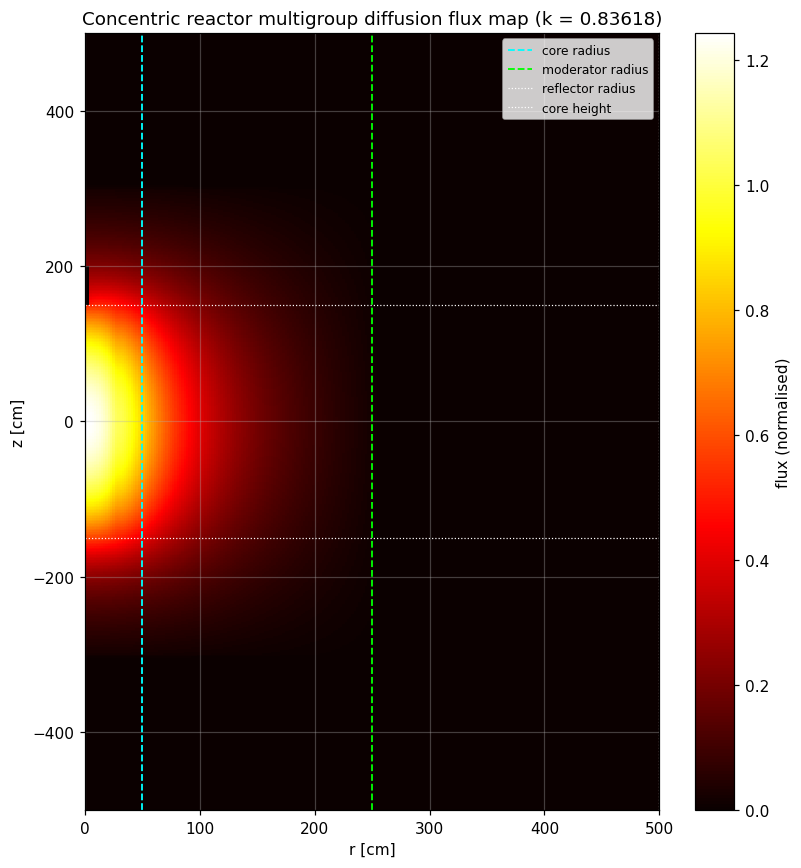

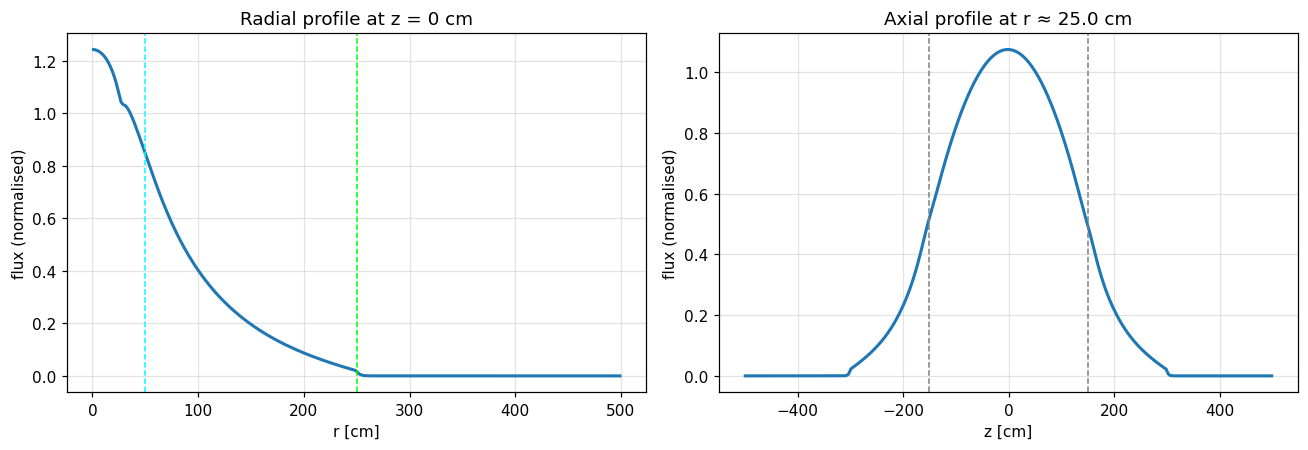

In [16]:
phi_clean = sol_clean["phi"]
phi_groups_clean = sol_clean["phi_groups"]
r_grid = sol_clean["r_grid"]
z_grid = sol_clean["z_grid"]

fig, ax = plt.subplots(figsize=(7.5, 8.0))
image = ax.pcolormesh(r_grid, z_grid, phi_clean.T, cmap="hot", shading="auto")
ax.axvline(GEOMETRY["core_radius_cm"], color="cyan", lw=1.2, ls="--", label="core radius")
ax.axvline(GEOMETRY["moderator_radius_cm"], color="lime", lw=1.2, ls="--", label="moderator radius")
ax.axvline(GEOMETRY["reflector_radius_cm"], color="white", lw=0.8, ls=":", label="reflector radius")
ax.axhline(model_2d.core_height / 2, color="white", lw=0.8, ls=":", label="core height")
ax.axhline(-model_2d.core_height / 2, color="white", lw=0.8, ls=":")
plt.colorbar(image, ax=ax, label="flux (normalised)")
ax.set_xlabel("r [cm]")
ax.set_ylabel("z [cm]")
ax.set_title(f"Concentric reactor multigroup diffusion flux map (k = {k_diff:.5f})")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

midplane_index = int(np.argmin(np.abs(z_grid - 0.0)))
axial_probe_radius_cm = 0.5 * GEOMETRY["core_radius_cm"]
axial_index = int(np.argmin(np.abs(r_grid - axial_probe_radius_cm)))

fig, (ax_r, ax_z) = plt.subplots(1, 2, figsize=(12, 4.2))
ax_r.plot(r_grid, phi_clean[:, midplane_index], lw=2)
ax_r.axvline(GEOMETRY["core_radius_cm"], color="cyan", lw=1.0, ls="--")
ax_r.axvline(GEOMETRY["moderator_radius_cm"], color="lime", lw=1.0, ls="--")
ax_r.set_xlabel("r [cm]")
ax_r.set_ylabel("flux (normalised)")
ax_r.set_title("Radial profile at z = 0 cm")

ax_z.plot(z_grid, phi_clean[axial_index, :], lw=2)
ax_z.axvline(model_2d.core_height / 2, color="gray", lw=1.0, ls="--")
ax_z.axvline(-model_2d.core_height / 2, color="gray", lw=1.0, ls="--")
ax_z.set_xlabel("z [cm]")
ax_z.set_ylabel("flux (normalised)")
ax_z.set_title(f"Axial profile at r ≈ {r_grid[axial_index]:.1f} cm")

plt.tight_layout()
plt.show()

## 4. Equivalent Rod-Insertion Scan

The OpenMC clean-core MGXS export does not yet provide rodded homogenized constants, so this section still uses an equivalent absorber perturbation: a cylindrical absorber with the real concentric rod radius is inserted from the top, and the added absorption is controlled by `DELTA_SIGMA_A_ROD`.

Use this as a fast parametric study, not as a transport-calibrated rod-worth prediction.

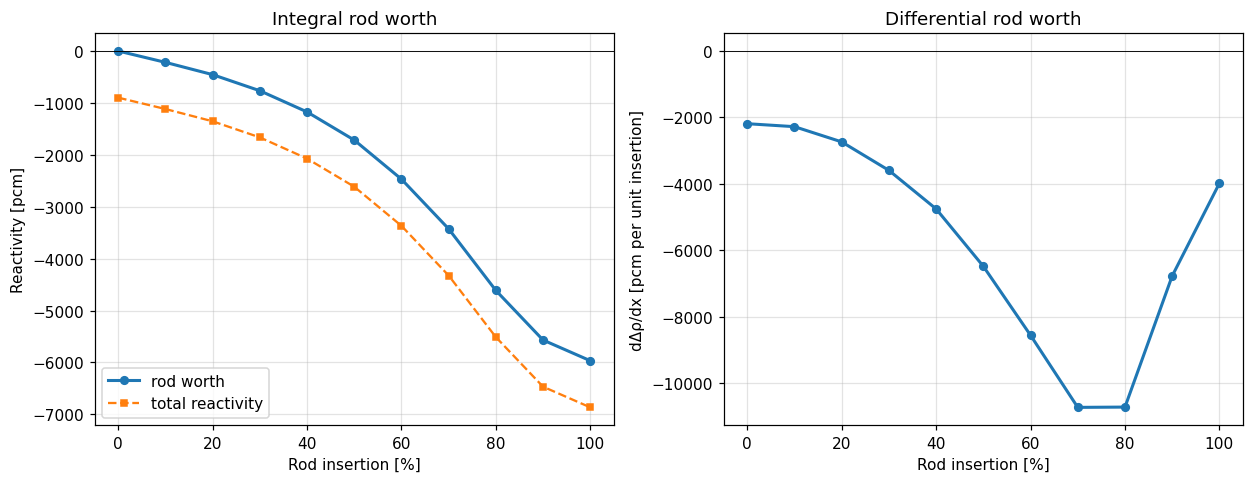

=== EQUIVALENT ROD SCAN ===
Clean-core reactivity         = -898.8 pcm
Full insertion rod worth      = -5966.2 pcm
Full insertion total rho      = -6865.0 pcm
Critical insertion fraction   = not crossed in this scan


In [8]:
scan = scan_multigroup_rod_worth_2d(
    model_2d,
    x_values=np.linspace(0.0, 1.0, 11),
    dr=DR_CM,
    dz=DZ_CM,
    max_iter=250,
    tol=1e-6,
    warm_start=True,
    )

x_insert = scan["x_insert"]
k_scan = scan["k_eff"]
delta_rho_pcm = scan["delta_rho_pcm"]
total_rho_pcm = scan["rho_total_pcm"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.5))
ax1.plot(x_insert * 100, delta_rho_pcm, "o-", lw=2, ms=5, label="rod worth")
ax1.plot(x_insert * 100, total_rho_pcm, "s--", lw=1.5, ms=4, label="total reactivity")
ax1.axhline(0.0, color="black", lw=0.6)
ax1.set_xlabel("Rod insertion [%]")
ax1.set_ylabel("Reactivity [pcm]")
ax1.set_title("Integral rod worth")
ax1.legend(loc="best")

differential_worth = np.gradient(delta_rho_pcm, x_insert)
ax2.plot(x_insert * 100, differential_worth, "o-", lw=2, ms=5)
ax2.axhline(0.0, color="black", lw=0.6)
ax2.set_xlabel("Rod insertion [%]")
ax2.set_ylabel("dΔρ/dx [pcm per unit insertion]")
ax2.set_title("Differential rod worth")

plt.tight_layout()
plt.show()

critical_insertion = scan["critical_insertion_fraction"]
print("=== EQUIVALENT ROD SCAN ===")
print(f"Clean-core reactivity         = {scan['rho_clean_pcm']:+.1f} pcm")
print(f"Full insertion rod worth      = {delta_rho_pcm[-1]:+.1f} pcm")
print(f"Full insertion total rho      = {total_rho_pcm[-1]:+.1f} pcm")
if critical_insertion is not None:
    print(f"Critical insertion fraction   = {critical_insertion*100:.1f} %")
else:
    print("Critical insertion fraction   = not crossed in this scan")

## 5. Interpretation

This notebook now uses the OpenMC concentric geometry with the same axial-plus-radial layering and the exported multigroup MGXS data, which removes the earlier one-group and off-axis material-map mismatch. The rod model is still approximate: the clean-core constants come from OpenMC MGXS, but the rodded cases still rely on an equivalent homogenized absorber increment. If tighter agreement is needed after this fix, the next calibration step is to generate rodded MGXS states or apply SPH / discontinuity-factor corrections to the homogenized regions.